# Match galaxies in MaNGA sample with galaxies in Illustris TNG 100-1

#### imports

In [1]:
import illustris_python as il
import matplotlib.pyplot as plt
from astropy.table import Table
import h5py
import numpy as np
import numpy.ma as ma
import tqdm
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib.lines import Line2D

from scipy.optimize import linear_sum_assignment
from scipy.spatial import KDTree

import sys
sys.path.insert(1, '/Users/nityaravi/Documents/GitHub/RotationCurves/ellipticals/')

from analyze_data import dist_cost_matrix


In [2]:
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['savefig.dpi'] = 300

In [3]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/paper_plots/final/gaussian_fits/paper_plots/IllustrisTNG/'

#### load catalogs 

In [4]:
base_path = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/TNG100-1/'
fields = ['SubhaloFlag',  'SubhaloMassInRadType', 
          # 'SubhaloMass', 'SubhaloMassInHalfRad',
          'SubhaloVmax', 'SubhaloVmaxRad', 
          # 'SubhaloStellarPhotometricsMassInRad','SubhaloStellarPhotometricsRad', 'SubhaloHalfmassRadType', 
          # 'SubhaloSFR','SubhaloGasMetalFractions', 'SubhaloStarMetallicity'
         ]
data = il.groupcat.loadSubhalos(base_path,99,fields=fields)

In [5]:
sdss_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc_099.hdf5'

In [6]:
master_table = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v9.fits')
test_sfr = master_table['SFR'][master_table['plateifu'] == '8997-9102']
test_mstar = master_table['sphd_M_star_h'][master_table['plateifu'] == '8997-9102']

In [109]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

## sdss table

In [7]:
sdss = h5py.File(sdss_fn)

## add stuff to tables 

### adjust the stellar masses of illustrisTNG to salpeter IMF
according to Longhetti et al. 2009 $$M_{\rm Chabrier} = 0.55M_{\rm Salpeter}$$

In [57]:
data['SubhaloMassInRadStar'] = np.log10(data['SubhaloMassInRadType'][:,4]) + 10
data['SubhaloMassInRadStar_Salpeter'] = data['SubhaloMassInRadStar'] - np.log10(0.55)
data['SubhaloID'] = sdss['subhaloIDs']

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_14661/1867860682.py:1: RuntimeWarning: divide by zero encountered in log10
  data['SubhaloMassInRadStar'] = np.log10(data['SubhaloMassInRadType'][:,4]) + 10


### add colors to master table and tng table

In [11]:
data['Subhalo_SDSS_u_r'] = sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,0,0] - sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,2,0]
master_table['nsa_u_r'] = master_table['nsa_elpetro_absmag'][:,2] - master_table['nsa_elpetro_absmag'][:, 4]

## plot galaxy mass and u - r color

In [12]:
spirals = master_table[master_table['spiral_mask'] == 1]
ellipticals = master_table[master_table['elliptical_mask']==1]

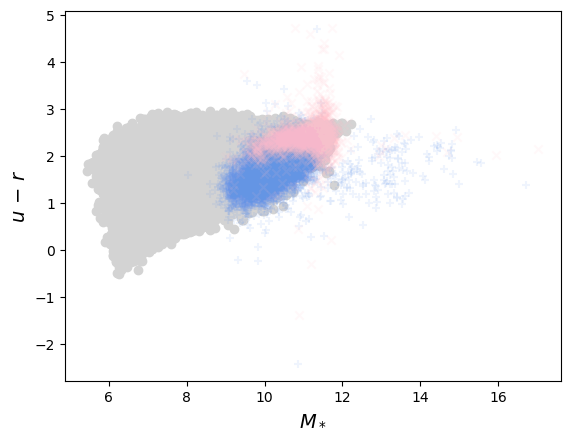

In [14]:
plt.scatter(data['SubhaloMassInRadStar'], data['Subhalo_SDSS_u_r'],
           marker='o', alpha =1, color='lightgrey', label='Illustris TNG 100-1'
           )

plt.xlabel(r'$M_*$', fontsize=14)
plt.ylabel(r'$u\,-\,r$', fontsize=14)

plt.scatter(spirals['sphd_M_star_h'], spirals['nsa_u_r'],
           marker='+', color='cornflowerblue', alpha=0.1)

plt.scatter(ellipticals['sphd_M_star_h'], ellipticals['nsa_u_r'],
           marker='x', color='pink', alpha=0.1)

(0.0, 4.0)

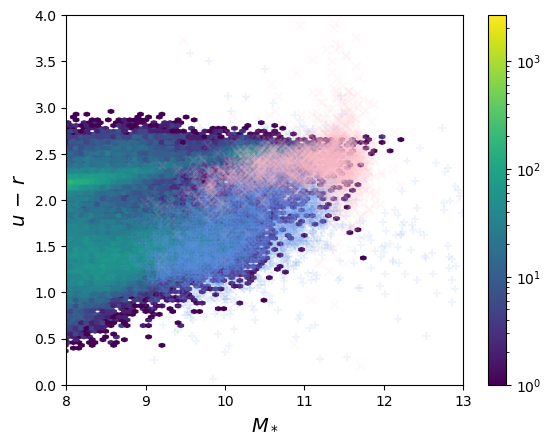

In [15]:
# plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4])+10,
#     sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,0,0]
#             - sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,2,0],
#            marker='o', alpha =1, color='lightgrey', label='Illustris TNG 100-1'
#            )

plt.hexbin(data['SubhaloMassInRadStar'], 
           data['Subhalo_SDSS_u_r'], bins='log')
plt.colorbar()

plt.xlabel(r'$M_*$', fontsize=14)
plt.ylabel(r'$u\,-\,r$', fontsize=14)

plt.scatter(spirals['sphd_M_star_h'], spirals['nsa_u_r'],
           marker='+', color='cornflowerblue', alpha=0.1)

plt.scatter(ellipticals['sphd_M_star_h'], ellipticals['nsa_u_r'],
           marker='x', color='pink', alpha=0.1)
plt.xlim(8,13)
plt.ylim(0,4)

#### plot the u-r vs mstar with new mstar

(0.0, 4.0)

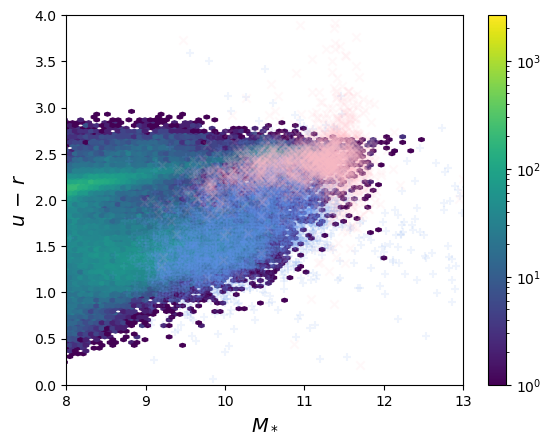

In [16]:
plt.hexbin(data['SubhaloMassInRadStar_Salpeter'], 
           data['Subhalo_SDSS_u_r'], bins='log')
plt.colorbar()

plt.xlabel(r'$M_*$', fontsize=14)
plt.ylabel(r'$u\,-\,r$', fontsize=14)

plt.scatter(spirals['sphd_M_star_h'], spirals['nsa_u_r'],
           marker='+', color='cornflowerblue', alpha=0.1)

plt.scatter(ellipticals['sphd_M_star_h'], ellipticals['nsa_u_r'],
           marker='x', color='pink', alpha=0.1)
plt.xlim(8,13)
plt.ylim(0,4)

### for tng galaxies matched to multiple manga gals, keep closest match 

### iterative matching, same process but remove matched galaxies from sample

In [213]:
mask_manga_i = np.logical_and(np.logical_or(master_table['spiral_mask'] == 1, 
                                       master_table['elliptical_mask']==1), best_matches == -999)


which_round = np.ones(len(master_table), int)*-999
current_round=0

best_matches = np.ones(len(master_table), int)*-999
best_dist = np.ones(len(master_table))*-999

best_matches_i = np.ones(len(master_table))

while len(master_table[mask_manga_i]) > 0 and len(best_matches_i[best_matches_i >=0]) > 0:

    print('current round: ', current_round)

    print('gals left ', len(master_table[mask_manga_i]))

    manga_ids = master_table[mask_manga_i]['plateifu']
    manga_u_r = master_table[mask_manga_i]['nsa_u_r']
    manga_mstar = master_table[mask_manga_i]['sphd_M_star_h']

    mask_tng_i = np.ones(len(data['SubhaloID']), bool)
    mask_tng_i[np.sort(best_matches[best_matches > -999])] = 0
    mask_tng_i = np.logical_and(mask_tng_i, data['SubhaloFlag'])
    mask_tng_i = np.logical_and(mask_tng_i, data['SubhaloMassInRadType'][:,4] > 0)
    
    tng_ids = data['SubhaloID'][mask_tng_i]
    tng_u_r = data['Subhalo_SDSS_u_r'][mask_tng_i]
    tng_mstar = data['SubhaloMassInRadStar_Salpeter'][mask_tng_i]


    best_matches_i = np.ones(len(manga_ids), int)*-999
    best_dist_i = np.ones(len(manga_ids))*-999

    for i in tqdm.tqdm(range(len(manga_ids))):
    
    # for i in range(2):
        
        dists = np.hypot(tng_u_r - manga_u_r[i], 
                        tng_mstar - manga_mstar[i])
    
        loc = np.nanargmin(dists)
        subhalo_id = tng_ids[loc]
    
        
        best_matches_i[i] = subhalo_id
        best_dist_i[i] = dists[loc]

    best_matches_i[best_dist_i > 0.2] = -9999
    best_dist_i[best_dist_i > 0.2] = -9999

    unique_matches, counts = np.unique(best_matches_i, return_counts=True)

    for i in range(len(unique_matches)):
    
        subhaloid = unique_matches[i]
        if subhaloid == -999: # ignore non-matches
            continue
    
        if counts[i] > 1:
            
            indices = np.where(best_matches_i == subhaloid)[0] # find where the match is in master_table
            dists = best_dist_i[indices] # find all the distances
            rem_ind = indices[np.arange(len(indices))!=np.argmin(dists)] 
    
            best_matches_i[rem_ind] = -999
            best_dist_i[rem_ind] = -999

    print('good_matches this round: ', len(best_matches_i[best_matches_i >=0]))
    print('unique matches this round: ', len(np.unique(best_matches_i))-2)

    for i in range(len(manga_ids)):
        master_index = master_table_dict[manga_ids[i]]
        if best_matches_i[i] >= 0:
            which_round[master_index] = current_round
        best_matches[master_index] = best_matches_i[i]
        best_dist[master_index] = best_dist_i[i]

    print('total good matches: ', len(best_matches[best_matches >=0]))
    print('double check: ', len(which_round[which_round>=0]))


    mask_manga_i = np.logical_and(np.logical_or(master_table['spiral_mask'] == 1, 
                                       master_table['elliptical_mask']==1), best_matches == -999)
    current_round += 1

    

current round:  0
gals left  8086


100%|█████████████████████████████████████| 8086/8086 [00:04<00:00, 1859.18it/s]


good_matches this round:  4245
unique matches this round:  4245
total good matches:  4245
double check:  4245
current round:  1
gals left  3840


100%|█████████████████████████████████████| 3840/3840 [00:01<00:00, 1969.42it/s]


good_matches this round:  893
unique matches this round:  893
total good matches:  5138
double check:  5138
current round:  2
gals left  2946


...

good_matches this round:  1
unique matches this round:  1
total good matches:  5746
double check:  5746
current round:  16
gals left  2324


100%|█████████████████████████████████████| 2324/2324 [00:01<00:00, 1909.88it/s]


good_matches this round:  1
unique matches this round:  1
total good matches:  5747
double check:  5747
current round:  17
gals left  2322


100%|█████████████████████████████████████| 2322/2322 [00:01<00:00, 1949.46it/s]


good_matches this round:  0
unique matches this round:  0
total good matches:  5747
double check:  5747


### add info to table

In [214]:
master_table['illustris_match'] = best_matches
master_table['illustris_dist'] = best_dist



master_table['illustris_u_r'] = np.ones(len(master_table))*-999
master_table['illustris_Mstar'] = np.ones(len(master_table))*-999
master_table['illustris_Mstar_Sal'] = np.ones(len(master_table))*-999
master_table['illustris_Vmax'] = np.ones(len(master_table))*-999
master_table['illustris_flag'] = np.ones(len(master_table))*-999

for i in range(len(master_table)):
    
    if master_table['illustris_match'][i] >=0:
        haloid = master_table['illustris_match'][i]
        master_table['illustris_u_r'][i] = data['Subhalo_SDSS_u_r'][haloid]
        master_table['illustris_Mstar'][i] = data['SubhaloMassInRadStar'][haloid]
        master_table['illustris_Mstar_Sal'][i] = data['SubhaloMassInRadStar_Salpeter'][haloid]
        master_table['illustris_Vmax'][i] = data['SubhaloVmax'][haloid]
        master_table['illustris_flag'][i] = data['SubhaloFlag'][haloid]

### plots

In [225]:
sample_mask = np.logical_and(master_table['illustris_match'] >= 0,
                            np.logical_or(master_table['spiral_mask']==1, master_table['elliptical_mask']==1))

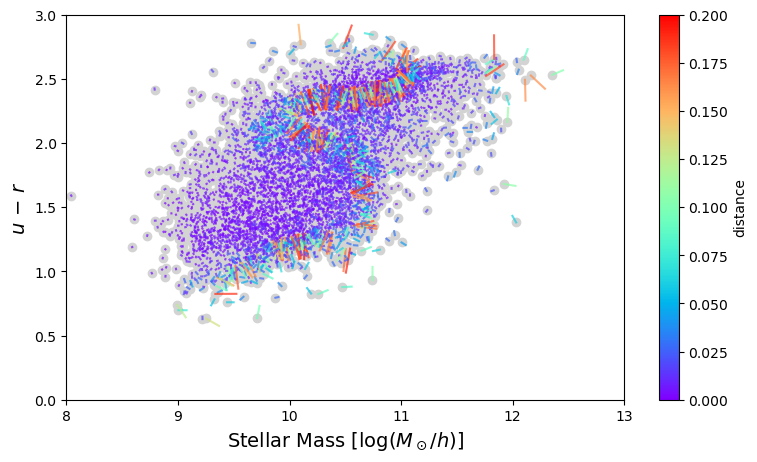

In [238]:
cmap = plt.get_cmap('rainbow')
fig,ax = plt.subplots(1,1, figsize=(9,5))
count = 0

# plt.gca().set_aspect("equal")
plt.scatter(master_table[sample_mask]['illustris_Mstar_Sal'], 
            master_table[sample_mask]['illustris_u_r'], 
            marker='o', color='lightgrey', label='Illustris TNG 100-1')
for i in range(len(master_table)):

    if (master_table['spiral_mask'][i] == 1 or master_table['elliptical_mask'][i]==1) and master_table['illustris_match'][i] >=0:
        count += 1
        # plt.arrow(master_table['sphd_M_star'][i], master_table['nsa_u_r'][i], 
        #           master_table['illustris_Mstar_Sal'][i]-master_table['sphd_M_star_h'][i],
        #           master_table['illustris_u_r'][i] - master_table['nsa_u_r'][i],
        #           alpha=0.3, color=cmap(master_table['illustris_dist'][i]/0.2), head_width=0.03)


        # plt.quiver(master_table['sphd_M_star'][i], master_table['nsa_u_r'][i], 
        #           master_table['illustris_Mstar_Sal'][i]-master_table['sphd_M_star_h'][i],
        #           master_table['illustris_u_r'][i] - master_table['nsa_u_r'][i],
        #           # alpha=0.3, color=cmap(master_table['illustris_dist'][i]/0.2), head_width=0.03
        #           )

        plt.plot([master_table['sphd_M_star_h'][i],master_table['illustris_Mstar_Sal'][i]],
                 [master_table['nsa_u_r'][i],master_table['illustris_u_r'][i]], 
                 alpha=0.7,color=cmap(master_table['illustris_dist'][i]/0.2)
                )


fig.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(0, 0.2), cmap='rainbow'),
             ax=ax, orientation='vertical', label='distance')





plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'$u\,-\,r$', fontsize=14)

plt.xlim(8,13)
plt.ylim(0,3)
plt.savefig(plot_dir + 'illustris_sample_unique_match_dist.png', bbox_inches='tight')

#### now plot by morphology

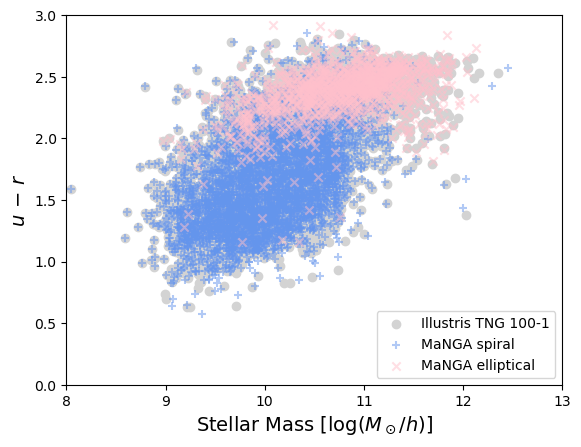

In [240]:
plt.scatter(master_table[sample_mask]['illustris_Mstar_Sal'], 
            master_table[sample_mask]['illustris_u_r'], 
            marker='o', color='lightgrey', label='Illustris TNG 100-1')
plt.scatter(master_table[np.logical_and(sample_mask,master_table['spiral_mask']==1)]['sphd_M_star_h'], 
            master_table[np.logical_and(sample_mask,master_table['spiral_mask']==1)]['nsa_u_r'], 
            marker='+', color='cornflowerblue', alpha=0.5, label='MaNGA spiral')
plt.scatter(master_table[np.logical_and(sample_mask,master_table['elliptical_mask']==1)]['sphd_M_star_h'], 
            master_table[np.logical_and(sample_mask,master_table['elliptical_mask']==1)]['nsa_u_r'],
            marker='x', color='pink', alpha=0.5, label='MaNGA elliptical')






plt.legend(loc='lower right')



plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'$u\,-\,r$', fontsize=14)

plt.xlim(8,13)
plt.ylim(0,3)
plt.savefig(plot_dir + 'illustris_sample_unique_match.png', bbox_inches='tight')

In [242]:
master_table.write('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v10.fits',
                  overwrite=True)

In [243]:
# veff 
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]


In [244]:
master_table['illustris_MR90'] = np.ones(len(master_table))*-999
for i in range(len(master_table)):
    if master_table['illustris_match'][i] >= 0:
        
        master_table['illustris_MR90'][i] = np.log10(master_table['illustris_Vmax'][i]**2 * master_table['R90_kpc'][i] / G)

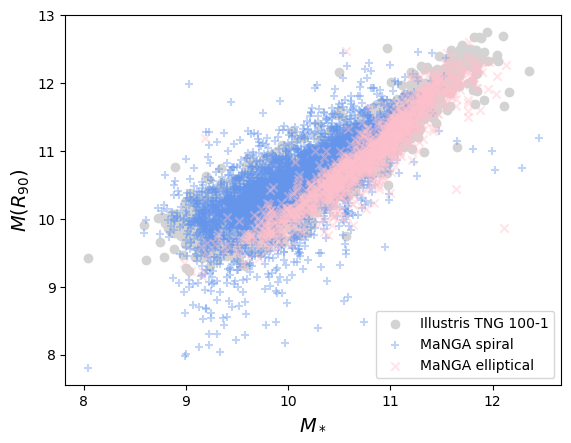

In [248]:
plt.scatter(master_table['illustris_Mstar_Sal'][master_table['illustris_match'] >= 0],
            master_table['illustris_MR90'][master_table['illustris_match'] >= 0], 
            marker='o', color='lightgrey', label='Illustris TNG 100-1')

plt.scatter(master_table[np.logical_and(master_table['spiral_mask']==1, master_table['illustris_match'] >= 0)]['sphd_M_star_h'],
            master_table[np.logical_and(master_table['spiral_mask']==1, master_table['illustris_match'] >= 0)]['M_R90'],
            marker='+', color='cornflowerblue', alpha=0.4, label='MaNGA spiral')

plt.scatter(master_table[np.logical_and(master_table['elliptical_mask']==1, master_table['illustris_match'] >= 0)]['sphd_M_star_h'],
            master_table[np.logical_and(master_table['elliptical_mask']==1, master_table['illustris_match'] >= 0)]['Mvir'],
            marker='x', color='pink', alpha=0.4, label='MaNGA elliptical')

plt.legend()
plt.xlabel(r'$M_*$', fontsize=14)
plt.ylabel(r'$M(R_{90})$', fontsize=14)
plt.savefig(plot_dir + 'illustris_match_shmr.png', bbox_inches='tight')

In [249]:
master_table.write('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v10.fits',
                  overwrite=True)

## HI H2 catalog
lets use Gnedin & Kravtsov 2011

In [255]:
gas_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/hih2_galaxy_099.hdf5'
gas = h5py.File(gas_fn)

### keys
'id_subhalo', 'm_h2_S14_vol', 'm_hi_S14_vol', 'm_neutral_H'

In [299]:
gas_dict = {}
for i in tqdm.tqdm(range(len(gas['id_subhalo']))):
    gas_dict[gas['id_subhalo'][i]] = i

100%|████████████████████████████████| 152122/152122 [00:13<00:00, 11585.74it/s]


In [328]:
master_table['MH2_S14_vol'] = np.ones(len(master_table))*-999
master_table['MHI_S14_vol']  = np.ones(len(master_table))*-999
master_table['MHtot'] = np.ones(len(master_table))*-999

for i in tqdm.tqdm(range(len(master_table))):

    match_id = master_table['illustris_match'][i]
    if match_id >= 0:
        try:
            gas_index = gas_dict[match_id]
        except:
            print(match_id, ' not in gas cat')
            continue

        master_table['MH2_S14_vol'][i] = np.log10(gas['m_h2_S14_vol'][gas_index]) + np.log10(0.6774)
        master_table['MHI_S14_vol'][i] = np.log10(gas['m_hi_S14_vol'][gas_index])  + np.log10(0.6774)
        master_table['MHtot'][i] = np.log10(gas['m_neutral_H'][gas_index])  + np.log10(0.6774)

  0%|                                                 | 0/11273 [00:00<?, ?it/s]/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_14661/2709638674.py:15: RuntimeWarning: divide by zero encountered in log10
  master_table['MH2_S14_vol'][i] = np.log10(gas['m_h2_S14_vol'][gas_index]) + np.log10(0.6774)
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_14661/2709638674.py:16: RuntimeWarning: divide by zero encountered in log10
  master_table['MHI_S14_vol'][i] = np.log10(gas['m_hi_S14_vol'][gas_index])  + np.log10(0.6774)
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_14661/2709638674.py:17: RuntimeWarning: divide by zero encountered in log10
  master_table['MHtot'][i] = np.log10(gas['m_neutral_H'][gas_index])  + np.log10(0.6774)
100%|███████████████████████████████████| 11273/11273 [00:03<00:00, 3614.00it/s]


In [329]:
master_table['MHtot'][master_table['MHtot'] == -np.inf]=0
master_table['MH2_S14_vol'][master_table['MH2_S14_vol'] == -np.inf]=0
master_table['MHI_S14_vol'][master_table['MHI_S14_vol'] == -np.inf]=0

In [330]:
master_table.write('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v10.fits',
                  overwrite=True)

## SHMR and BTFR

In [331]:
spirals_matched = master_table[np.logical_and(master_table['spiral_mask']==1, master_table['illustris_match']>=0)]
ellipticals_matched = master_table[np.logical_and(master_table['elliptical_mask']==1, master_table['illustris_match']>=0)]

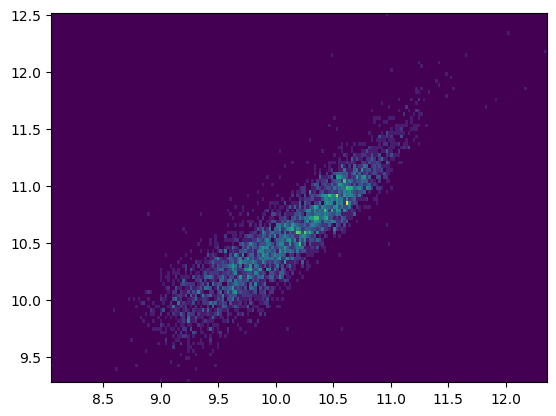

In [343]:
h,xs,ys,im  = plt.hist2d(spirals_matched['illustris_Mstar_Sal'], spirals_matched['illustris_MR90'], bins=(200,100))

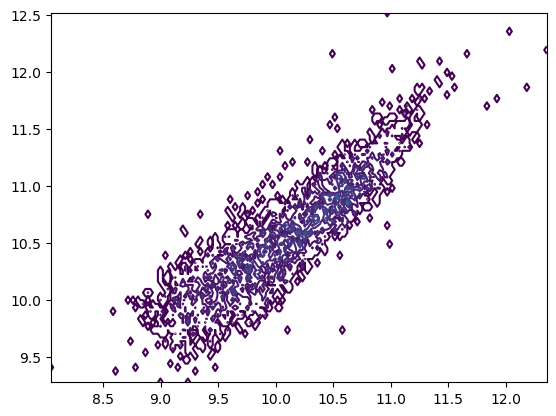

In [352]:
plt.contour(h.transpose(), extent=[xs.min(), xs.max(), ys.min(), ys.max()],
           levels=np.linspace(0,35,20) 
           )

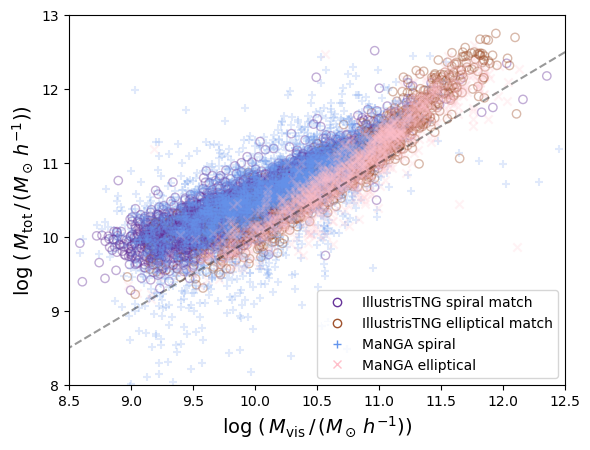

In [366]:
plt.scatter(spirals_matched['illustris_Mstar_Sal'], spirals_matched['illustris_MR90'],
           color='rebeccapurple', alpha=0.4, marker='o', facecolor='none')
plt.scatter(ellipticals_matched['illustris_Mstar_Sal'], ellipticals_matched['illustris_MR90'],
           color='sienna', alpha=0.4, marker='o', facecolor='none')
plt.scatter(spirals_matched['sphd_M_star_h'], spirals_matched['M_R90'],
           color='cornflowerblue',marker='+', alpha=0.2)
plt.scatter(ellipticals_matched['sphd_M_star_h'], ellipticals_matched['Mvir'],
           color='pink',marker='x', alpha=0.2)

plt.xlim(8.5,12.5)
plt.plot([7,14],[7,14], linestyle='--', color='k', alpha=0.4)
plt.ylim(8,13)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='IllustrisTNG spiral match',
                          markeredgecolor='rebeccapurple', markerfacecolor='none', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='IllustrisTNG elliptical match',
                          markeredgecolor='sienna', markerfacecolor='none', markersize=6),
                  Line2D([0], [0], marker='+', color='w', label='MaNGA spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='MaNGA elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6)]


plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.xlabel(r'$\log\,(\,M_{\rm vis}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

plt.legend(handles=legend_elements)

# OLD MATCHING (SFR)

## match galaxies using Mstar within 2*R50 and SFR (10 Myr)

In [6]:
# find closst match in sfr
dist2 = (np.log10(sfr['SubhaloMassInRadStar']) + 10 - test_mstar)**2 + (np.log10(sfr['SFR_InRadStar_10Myr']) - test_sfr)**2

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/2713027700.py:2: RuntimeWarning: divide by zero encountered in log10
  dist2 = (np.log10(sfr['SubhaloMassInRadStar']) + 10 - test_mstar)**2 + (np.log10(sfr['SFR_InRadStar_10Myr']) - test_sfr)**2


In [7]:
sfr[np.argmin(dist2)]

SubfindID,SubhaloFlag,SubhaloVmax,SubhaloMass,SubhaloMassInRadStar,SubhaloHalfmassRadStar,SubhaloStellarPhotometricsMassInRad,SubjaloStellarPhotometricsRad,SFR_10Myr,SFR_InRadStar_10Myr
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64
501903,1.0,189.8396759033203,63.411964416503906,1.8252849578857422,3.346299171447754,1.840047836303711,1.840047836303711,2.6537609765706742,1.5716191968207742


In [8]:
test_sfr

0.192511375469816


In [9]:
test_mstar

10.2553222677357


In [10]:
np.log10(sfr['SubhaloMassInRadStar'][np.argmin(dist2)]) + 10

10.261330674807109

In [11]:
np.log10(sfr['SFR_InRadStar_10Myr'][np.argmin(dist2)])

0.19634732493896345

In [12]:
np.random.rand(len(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0]))-5

array([-4.11136432, -4.33593519, -4.21775739, ..., -4.15184317,
       -4.07122407, -4.17162604])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/3645279682.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]), marker='.', alpha=0.1, label='IllustrisTNG 100')


Text(0, 0.5, 'SFR $[\\log(M_\\odot/\\rm yr)]$')

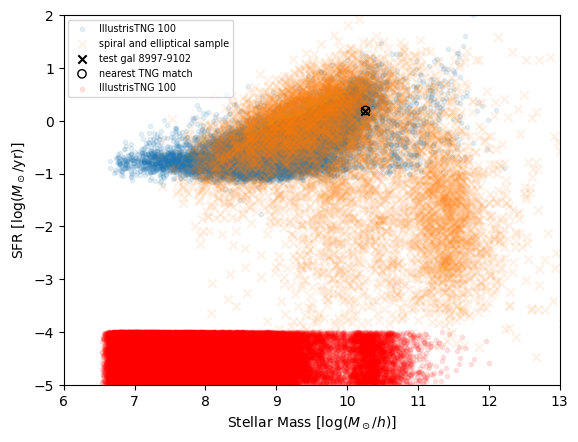

In [13]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10,
            np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]), marker='.', alpha=0.1, label='IllustrisTNG 100')
plt.scatter(master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['sphd_M_star_err_h'], 
            master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['SFR'], marker='x', alpha=0.1,
           label='spiral and elliptical sample')
plt.scatter(master_table['sphd_M_star_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][np.argmin(dist2)]) + 10,
            np.log10(sfr['SFR_InRadStar_10Myr'][np.argmin(dist2)]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')

plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0]) + 10,
            np.random.rand(len(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0])) + -5, color='r', marker='.', alpha=0.1, label='IllustrisTNG 100')


plt.legend(fontsize='x-small')
plt.xlim(6,13)
plt.ylim(-5,2)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$')
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$')

### SFR vs Mstar but with MaNGA sample colored by morph

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/757935654.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]), marker='.', alpha=1, label='IllustrisTNG 100', color='lightgrey')


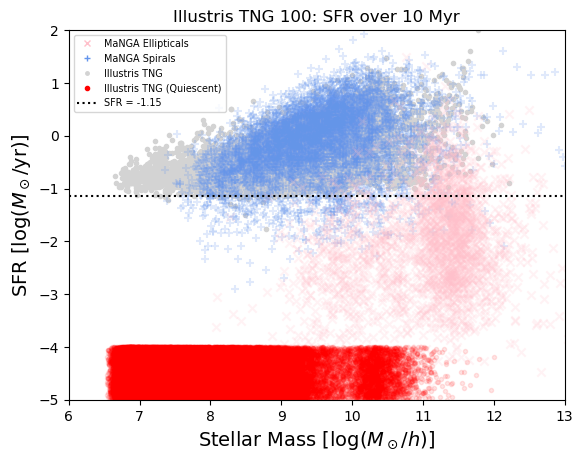

In [38]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10,
            np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]), marker='.', alpha=1, label='IllustrisTNG 100', color='lightgrey')
plt.scatter(master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['spiral_mask']==1]['SFR'], marker='+', alpha=0.2,
           label='spiral sample', color='cornflowerblue')



plt.scatter(master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['elliptical_mask']==1]['SFR'], marker='x', alpha=0.2,
           label='elliptical sample', color='pink' )
# plt.scatter(master_table['sphd_M_star_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

# plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][np.argmin(dist2)]) + 10,
#             np.log10(sfr['SFR_InRadStar_10Myr'][np.argmin(dist2)]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')

plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0]) + 10,
            np.random.rand(len(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0])) + -5, color='r', marker='.', alpha=0.1, label='IllustrisTNG 100')



legend_elements = [Line2D([0], [0], marker='x', color='w', label='MaNGA Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='MaNGA Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG',
                          markeredgecolor='lightgrey', markerfacecolor='lightgrey', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG (Quiescent)',
                          markeredgecolor='r', markerfacecolor='r', markersize=6),
                  Line2D([0], [0], marker='none', linestyle=':', color='k', label='SFR = -1.15')]


plt.legend(handles=legend_elements, fontsize='x-small')
plt.axhline(-1.15, color='k', linestyle=':')
plt.xlim(6,13)
plt.ylim(-5,2)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$', fontsize=14)

plt.title('Illustris TNG 100: SFR over 10 Myr')
plt.savefig(plot_dir + 'spiral_elliptical_SFR_10Myr.png', bbox_inches='tight')

#### remade with specific star formation rate

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/870014476.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]) - (np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10),


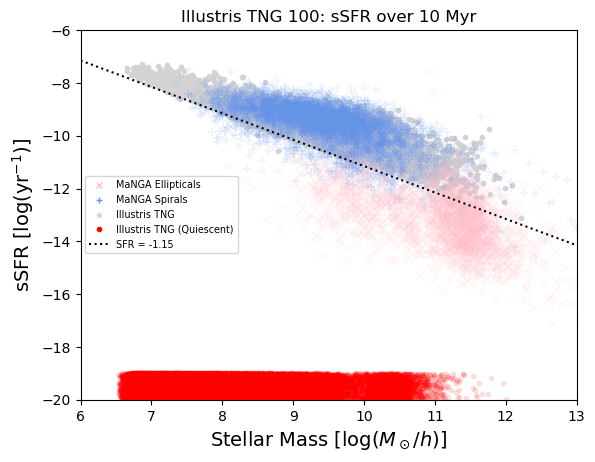

In [49]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10,
            np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]) - (np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10),
            marker='.', alpha=1, label='IllustrisTNG 100', color='lightgrey')
plt.scatter(master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['spiral_mask']==1]['SFR'] - master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'], 
            marker='+', alpha=0.1,
           label='spiral sample', color='cornflowerblue')



plt.scatter(master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['elliptical_mask']==1]['SFR'] - master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'],
            marker='x', alpha=0.1,
           label='elliptical sample', color='pink' )

plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0]) + 10,
            np.random.rand(len(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0])) + -20, color='r', marker='.', alpha=0.1, label='IllustrisTNG 100')



legend_elements = [Line2D([0], [0], marker='x', color='w', label='MaNGA Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='MaNGA Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG',
                          markeredgecolor='lightgrey', markerfacecolor='lightgrey', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG (Quiescent)',
                          markeredgecolor='r', markerfacecolor='r', markersize=6),
                  Line2D([0], [0], marker='none', linestyle=':', color='k', label='SFR = -1.15')]


plt.legend(handles=legend_elements, fontsize='x-small')
# plt.axhline(-1.15, color='k', linestyle=':')

plt.plot(np.linspace(6,13,100), -1.15 - np.linspace(6,13,100), color='k', linestyle=':')
plt.xlim(6,13)
plt.ylim(-20, -6)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'sSFR $[\log(\rm yr^{-1})]$', fontsize=14)

plt.title('Illustris TNG 100: sSFR over 10 Myr')
plt.savefig(plot_dir + 'spiral_elliptical_sSFR_10Myr.png', bbox_inches='tight')

## match galaxies using Mstar within 2*R50 and instantaneous SFR from z=0 snapshot (snapshot 99)

#### sanity check on velocity 

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/2674408995.py:2: RuntimeWarning: divide by zero encountered in log10
  c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10)


Text(0, 0.5, 'Subhalo Mass $[M_\\odot/h]$')

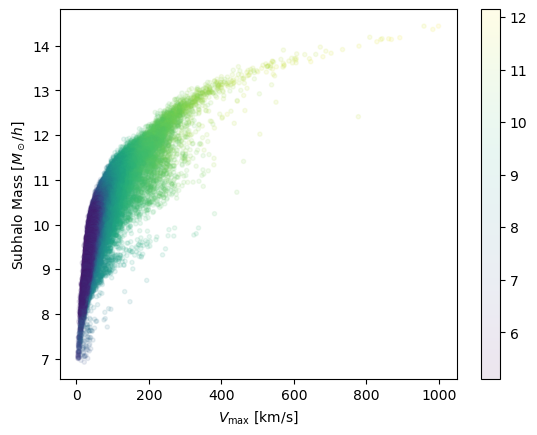

In [25]:
plt.scatter(data['SubhaloVmax'][data['SubhaloFlag']], np.log10(data['SubhaloMass'][data['SubhaloFlag']]) + 10, marker='.', alpha=0.1,
           c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10)
plt.colorbar()
plt.xlabel(r'$V_{\rm max}$ [km/s]')
plt.ylabel(r'Subhalo Mass $[M_\odot/h]$')

#### check which radius is more extended

In [26]:
r50_2 = data['SubhaloHalfmassRadType'][:,4]
r207 = data['SubhaloStellarPhotometricsRad']

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/287601697.py:2: RuntimeWarning: divide by zero encountered in log10
  c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) +  10,marker='.', s=0.5)


Text(0, 0.5, '20.7 mag/arcsec$^2$ K-band')

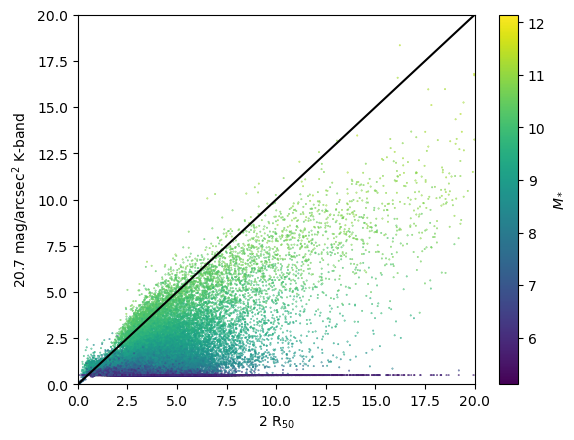

In [27]:
plt.scatter(r50_2[data['SubhaloFlag']]*2, r207[data['SubhaloFlag']], 
            c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) +  10,marker='.', s=0.5)
plt.xlim(0,20)
plt.ylim(0,20)
plt.plot([0,20],[0,20], color='k')
plt.colorbar(label=r'$M_*$')
plt.xlabel(r'2 R$_{50}$')
plt.ylabel(r'20.7 mag/arcsec$^2$ K-band')

In [69]:
dist2 = (np.log10(data['SubhaloMassInRadType'][:,4]) + 10 - master_table['sphd_M_star_err_h'][9080])**2 +\
            (np.log10(data['SubhaloSFR']) - master_table['SFR'][9080])**2

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/419658659.py:1: RuntimeWarning: divide by zero encountered in log10
  dist2 = (np.log10(data['SubhaloMassInRadType'][:,4]) + 10 - master_table['sphd_M_star_err_h'][9080])**2 +\
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/419658659.py:2: RuntimeWarning: divide by zero encountered in log10
  (np.log10(data['SubhaloSFR']) - master_table['SFR'][9080])**2


/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/4230633857.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10,
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/4230633857.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(data['SubhaloSFR'][data['SubhaloFlag']]), marker='.', alpha=1, label='IllustrisTNG 100',
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/4230633857.py:23: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]) + 10,


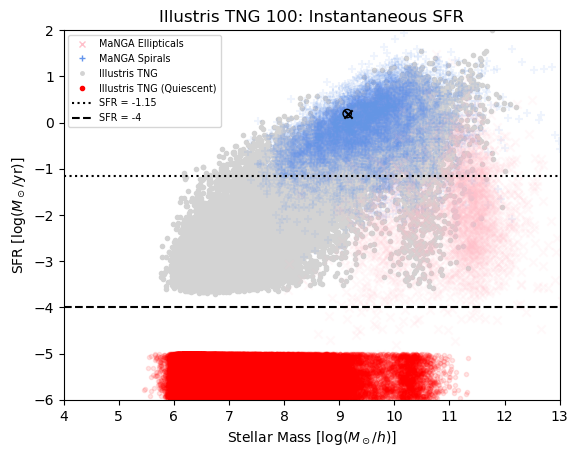

In [70]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10,
            np.log10(data['SubhaloSFR'][data['SubhaloFlag']]), marker='.', alpha=1, label='IllustrisTNG 100',
           color='lightgrey')





plt.scatter(master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['spiral_mask']==1]['SFR'], marker='+', alpha=0.1, color='cornflowerblue')

plt.scatter(master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['elliptical_mask']==1]['SFR'], marker='x', alpha=0.1, color='pink')


plt.scatter(master_table['sphd_M_star_err_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

plt.scatter(np.log10(data['SubhaloMassInRadType'][np.argmin(dist2)][4]) + 10,
            np.log10(data['SubhaloSFR'][np.argmin(dist2)]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')


plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]) + 10,
            np.random.rand(len(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]))-6, marker='.', color='r', alpha=0.1, label='IllustrisTNG 100 SFR=0')


legend_elements = [Line2D([0], [0], marker='x', color='w', label='MaNGA Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='MaNGA Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG',
                          markeredgecolor='lightgrey', markerfacecolor='lightgrey', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG (Quiescent)',
                          markeredgecolor='r', markerfacecolor='r', markersize=6),
                  Line2D([0], [0], marker='none', linestyle=':', color='k', label='SFR = -1.15'),
                  Line2D([0], [0], marker='none', linestyle='--', color='k', label='SFR = -4')]


plt.axhline(-1.15, linestyle=':', color='k')
plt.axhline(-4, linestyle='--', color='k')




plt.legend(handles=legend_elements, fontsize='x-small')
plt.xlim(4,13)
plt.ylim(-6,2)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$')
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$')

plt.title('Illustris TNG 100: Instantaneous SFR')
plt.savefig(plot_dir + 'spiral_elliptical_SFR_inst.png', bbox_inches='tight')

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1061631465.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10,
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1061631465.py:4: RuntimeWarning: divide by zero encountered in log10
  np.log10(data['SubhaloSFR'][data['SubhaloFlag']]) - (np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10),
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1061631465.py:4: RuntimeWarning: invalid value encountered in subtract
  np.log10(data['SubhaloSFR'][data['SubhaloFlag']]) - (np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10),
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1061631465.py:26: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]) + 10,


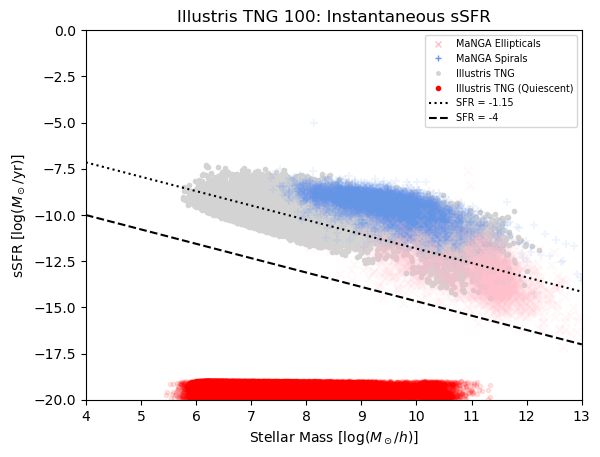

In [73]:
# first plot stellar mass vs sfr for tng gals and manga 

plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10,
            np.log10(data['SubhaloSFR'][data['SubhaloFlag']]) - (np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10), 
            marker='.', alpha=1, label='IllustrisTNG 100',
           color='lightgrey')




plt.scatter(master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['spiral_mask']==1]['SFR'] - master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'],
            marker='+', alpha=0.1, color='cornflowerblue')

plt.scatter(master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['elliptical_mask']==1]['SFR'] -master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'], 
            marker='x', alpha=0.1, color='pink')


# plt.scatter(master_table['sphd_M_star_err_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

# plt.scatter(np.log10(data['SubhaloMassInHalfRadType'][np.argmin(dist2)][4]) + 10,
#             np.log10(data['SubhaloSFR'][np.argmin(dist2)]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')


plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]) + 10,
            np.random.rand(len(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]))-20, marker='.', color='r', alpha=0.1, label='IllustrisTNG 100 SFR=0')


legend_elements = [Line2D([0], [0], marker='x', color='w', label='MaNGA Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='MaNGA Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG',
                          markeredgecolor='lightgrey', markerfacecolor='lightgrey', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG (Quiescent)',
                          markeredgecolor='r', markerfacecolor='r', markersize=6),
                  Line2D([0], [0], marker='none', linestyle=':', color='k', label='SFR = -1.15'),
                  Line2D([0], [0], marker='none', linestyle='--', color='k', label='SFR = -4')]


# plt.axhline(-1.15, linestyle=':', color='k')
# plt.axhline(-4, linestyle='--', color='k')


plt.plot(np.linspace(4,13,100), -1.15 - np.linspace(6,13,100), color='k', linestyle=':')
plt.plot(np.linspace(4,13,100), -4 - np.linspace(6,13,100), color='k', linestyle='--')


plt.legend(handles=legend_elements, fontsize='x-small')
plt.xlim(4,13)
plt.ylim(-18,0)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$')
plt.ylabel(r'sSFR $[\log(M_\odot/\rm yr)]$')

plt.title('Illustris TNG 100: Instantaneous sSFR')
plt.savefig(plot_dir + 'spiral_elliptical_sSFR_inst.png', bbox_inches='tight')

### adding corresponding tng gals to master table

take the distance between each MaNGA gal and Illustris TNG gals in stellar mass-SFR plane. extract vmax, stellar mass, sfr and distance

In [88]:
#### create subsample of good tng gals
good_halo_vmax = data['SubhaloVmax'][data['SubhaloFlag']]
good_halo_mstar = np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10
good_halo_sfr = np.log10(data['SubhaloSFR'][data['SubhaloFlag']])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1912976755.py:3: RuntimeWarning: divide by zero encountered in log10
  good_halo_mstar = np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1912976755.py:4: RuntimeWarning: divide by zero encountered in log10
  good_halo_sfr = np.log10(data['SubhaloSFR'][data['SubhaloFlag']])


In [89]:
master_table['TNG_Vmax'] = np.ones(len(master_table))*-999
master_table['TNG_Mstar'] = np.ones(len(master_table))*-999
master_table['TNG_SFR']= np.ones(len(master_table))*-999
master_table['TNG_distance']= np.ones(len(master_table))*-999
master_table['TNG_temp_idx']= np.ones(len(master_table))*-999

In [90]:
for i in tqdm.tqdm(range(len(master_table))):

    # check if gal in sample
    if master_table['elliptical_mask'][i] == 1 or master_table['spiral_mask'][i] == 1:

        manga_smass = master_table['sphd_M_star_h'][i]
        manga_sfr = master_table['SFR'][i]

        dists = (good_halo_mstar - manga_smass)**2 + (good_halo_sfr - manga_sfr)**2
        idx = np.argmin(dists)

        master_table['TNG_Vmax'][i] = good_halo_vmax[idx]
        master_table['TNG_Mstar'][i] = good_halo_mstar[idx]
        master_table['TNG_SFR'][i] = good_halo_sfr[idx]
        master_table['TNG_distance'][i] = np.sqrt(dists[idx])
        master_table['TNG_temp_idx'][i] = idx

  0%|                                       | 13/11273 [00:00<01:31, 123.21it/s]/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/astropy/table/column.py:1376: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value
100%|████████████████████████████████████| 11273/11273 [00:56<00:00, 199.24it/s]


In [94]:
idxs, counts = np.unique(master_table['TNG_temp_idx'], return_counts=True)
np.where(counts > 1)

(array([   0,    1,    2, ..., 3146, 3150, 3156]),)

In [93]:
sample = master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]

In [212]:
counts, bins = np.histogram(master_table['TNG_distance'], bins=np.linspace(0,5.2,50))
cmap = plt.get_cmap('rainbow')

In [208]:
cmap(5.2)

(1.0, 1.2246467991473532e-16, 6.123233995736766e-17, 1.0)

Text(0, 0.5, 'SFR $[\\log(M_\\odot/\\rm yr)]$')

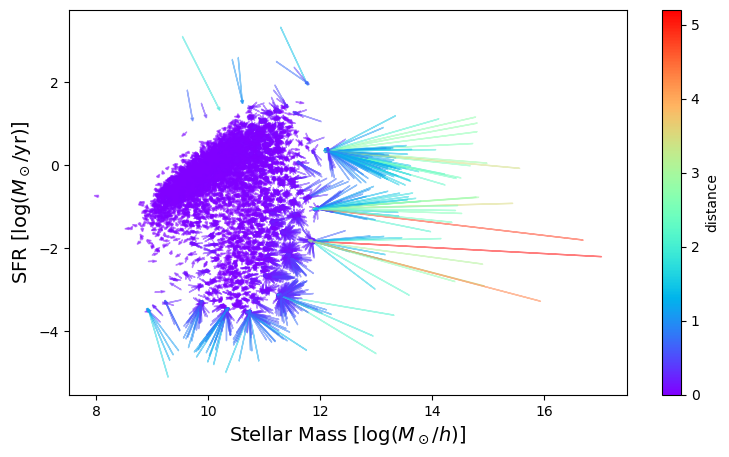

In [224]:
fig,ax = plt.subplots(1,1, figsize=(9,5))
for i in range(len(sample)):
    plt.arrow(sample['sphd_M_star_h'][i], sample['SFR'][i], 
              sample['TNG_Mstar'][i]-sample['sphd_M_star_h'][i], sample['TNG_SFR'][i]-sample['SFR'][i],
              alpha=0.5, color=cmap(sample['TNG_distance'][i]/5.2), head_width=0.05)

fig.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(0, 5.2), cmap='rainbow'),
             ax=ax, orientation='vertical', label='distance')

plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$', fontsize=14)

In [225]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]


In [227]:
master_table['TNG_MR90'] = np.ones(len(master_table))*-999
for i in range(len(master_table)):

    master_table['TNG_MR90'][i] = np.log10(master_table['TNG_Vmax'][i]**2 * master_table['R90_kpc'][i] / G)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_25923/1614506484.py:4: RuntimeWarning: invalid value encountered in log10
  master_table['TNG_MR90'][i] = np.log10(master_table['TNG_Vmax'][i]**2 * master_table['R90_kpc'][i] / G)


(7.5, 13.0)

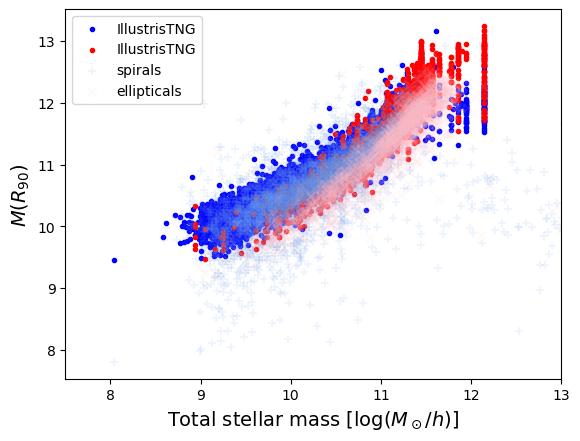

In [252]:
plt.scatter(master_table['TNG_Mstar'][master_table['spiral_mask']==1], 
            master_table['TNG_MR90'][master_table['spiral_mask']==1], alpha=1, marker='.', color='b', label='IllustrisTNG spiral match')
plt.scatter(master_table['TNG_Mstar'][master_table['elliptical_mask']==1], 
            master_table['TNG_MR90'][master_table['elliptical_mask']==1], alpha=1, marker='.', color='r', label='IllustrisTNG elliptical match')

plt.scatter(master_table['sphd_M_star_h'][master_table['spiral_mask']==1], 
            master_table['M_R90'][master_table['spiral_mask']==1], 
            alpha=0.1, marker='+', color='cornflowerblue', label='spirals')
plt.scatter(master_table['sphd_M_star_h'][master_table['elliptical_mask']==1], 
            master_table['Mvir'][master_table['elliptical_mask']==1], 
            alpha=0.1, marker='x', color='pink', label='ellipticals')
plt.xlabel(r'Total stellar mass $[\log(M_\odot/h)]$', fontsize=14)
plt.ylabel(r'$M(R_{90})$', fontsize=14)
plt.legend()
plt.xlim(7.5,13)

#### fun with assignment problems

In [1]:
mstar_tng, mstar_manga = np.meshgrid(good_halo_mstar, sample['sphd_M_star_h'])

NameError: name 'np' is not defined

## compare the two SFR measures for the same halos 

### first compare distributions of SFR, sSFR from all 3 pops

In [9]:
sfr_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/TNG100-1/star_formation_rates.hdf5'
sfr = h5py.File(sfr_fn, 'r')

In [17]:
for name in sfr['Snapshot_99']:
    print(name)

SFR_MsunPerYrs_in_InRad_1000Myrs
SFR_MsunPerYrs_in_InRad_100Myrs
SFR_MsunPerYrs_in_InRad_10Myrs
SFR_MsunPerYrs_in_InRad_200Myrs
SFR_MsunPerYrs_in_InRad_50Myrs
SFR_MsunPerYrs_in_all_1000Myrs
SFR_MsunPerYrs_in_all_100Myrs
SFR_MsunPerYrs_in_all_10Myrs
SFR_MsunPerYrs_in_all_200Myrs
SFR_MsunPerYrs_in_all_50Myrs
SFR_MsunPerYrs_in_r30pkpc_1000Myrs
SFR_MsunPerYrs_in_r30pkpc_100Myrs
SFR_MsunPerYrs_in_r30pkpc_10Myrs
SFR_MsunPerYrs_in_r30pkpc_200Myrs
SFR_MsunPerYrs_in_r30pkpc_50Myrs
SFR_MsunPerYrs_in_r5pkpc_1000Myrs
SFR_MsunPerYrs_in_r5pkpc_100Myrs
SFR_MsunPerYrs_in_r5pkpc_10Myrs
SFR_MsunPerYrs_in_r5pkpc_200Myrs
SFR_MsunPerYrs_in_r5pkpc_50Myrs
SubfindID


In [67]:
sfr['Snapshot_99']['SubfindID']

<HDF5 dataset "SubfindID": shape (116394,), type "<i4">

In [69]:
h = il.groupcat.loadSingle(base_path, 99, subhaloID=1)

In [70]:
h

{'SubhaloBHMass': 0.12551759,
 'SubhaloBHMdot': 0.0002301299,
 'SubhaloBfldDisk': 0.90148443,
 'SubhaloBfldHalo': 0.15268138,
 'SubhaloCM': array([  124.47653, 24606.768  , 16859.104  ], dtype=float32),
 'SubhaloFlag': True,
 'SubhaloGasMetalFractions': array([7.4376333e-01, 2.4799015e-01, 8.3335524e-04, 2.9013937e-04,
        4.0014386e-03, 1.3231143e-03, 3.8415098e-04, 3.9607051e-04,
        6.9444388e-04, 3.2380351e-04], dtype=float32),
 'SubhaloGasMetalFractionsHalfRad': array([7.3769665e-01, 2.5096405e-01, 1.1245606e-03, 4.1383362e-04,
        5.3651924e-03, 1.7890783e-03, 5.1718170e-04, 5.5794109e-04,
        1.0841856e-03, 4.8734748e-04], dtype=float32),
 'SubhaloGasMetalFractionsMaxRad': array([7.5244862e-01, 2.4395068e-01, 3.7734673e-04, 1.2004986e-04,
        1.8324659e-03, 5.9897872e-04, 1.7498418e-04, 1.6359941e-04,
        2.1959751e-04, 1.1368736e-04], dtype=float32),
 'SubhaloGasMetalFractionsSfr': array([7.4573088e-01, 2.4702457e-01, 7.0538727e-04, 2.3649352e-04,
      